## Landscape Classifier - Intel Image Classification Dataset
### Scene Recognition with ResNet50

This notebook implements a deep learning model to classify landscape images into 6 categories using ResNet50.
The dataset contains images organized in class folders: buildings, forest, glacier, mountain, sea, and street.

In [1]:
import os
import sys
import copy
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, WeightedRandomSampler
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
from tqdm import tqdm
from PIL import Image
from collections import Counter
from sklearn.metrics import (
    confusion_matrix, 
    ConfusionMatrixDisplay, 
    classification_report,
    balanced_accuracy_score,
    precision_recall_fscore_support
)

# Add scripts directory to path for custom imports
sys.path.insert(0, os.path.abspath('../scripts'))
from gpu_utils import CheckGPU, CheckCUDA, CheckGPUBrief
from dataset_counter import CountDataset

print("\u2705 All libraries and custom modules imported successfully!")

✅ All libraries and custom modules imported successfully!


#### Detect GPU Available, Details, Cuda, and cuDNN

In [2]:
# From scripts.gpu_utils
CheckGPU()
CheckCUDA()

🖥️  GPU INFORMATION
✅ GPU Detected         : NVIDIA GeForce RTX 2060
   • Device ID          : 0
   • Compute Capability : 7.5
   • Multiprocessors    : 30
   • Total VRAM         : 6.00 GB
   • VRAM Allocated     : 0.00 GB
   • VRAM Reserved      : 0.00 GB
   • Active Device      : cuda

⚡ CUDA / PYTORCH INFORMATION
✅ CUDA Available       : True
   • PyTorch CUDA Ver.  : 12.4
   • PyTorch Version    : 2.6.0+cu124
✅ cuDNN Version        : 90100
   • CUDA Device Count  : 1
   • Device 0 Name     : NVIDIA GeForce RTX 2060


### Global Configuration Variables

In [3]:
# ============================
# GLOBAL CONFIGURATION
# ============================

# Dataset paths (folder-based dataset, no CSV)
DATASET_DIR = "../data/raw/Datasets"

# Train/Validation/Test split ratios (no pre-split, we split from the full dataset)
TRAIN_SPLIT = 0.70   # 70% for training
VAL_SPLIT = 0.15     # 15% for validation
TEST_SPLIT = 0.15    # 15% for testing

# ============================
# AUGMENTATION CONFIGURATION
# ============================
USE_AUGMENTATION = True

# Individual augmentation toggles (only applied when USE_AUGMENTATION = True)
AUGMENTATION_OPTIONS = {
    "random_horizontal_flip": True,     # Flip images horizontally
    "random_rotation": True,            # Rotate images by up to ROTATION_DEGREES
    "random_affine": True,              # Translation and scale jitter
    "color_jitter": True,               # Brightness, contrast, saturation, hue
    "random_perspective": True,          # Perspective distortion
    "random_resized_crop": True,         # Random crop with resize (scale variation)
    "gaussian_blur": True,              # Slight blur for robustness
    "random_erasing": True,             # Simulates occlusion
}

# Augmentation parameters
ROTATION_DEGREES = 20                    # Max rotation angle
AFFINE_TRANSLATE = (0.1, 0.1)           # Max translation (fraction of image)
AFFINE_SCALE = (0.85, 1.15)             # Scale range
COLOR_BRIGHTNESS = 0.3                   # Brightness jitter
COLOR_CONTRAST = 0.3                     # Contrast jitter
COLOR_SATURATION = 0.3                   # Saturation jitter
COLOR_HUE = 0.1                          # Hue jitter
PERSPECTIVE_DISTORTION = 0.2             # Perspective distortion scale
PERSPECTIVE_PROB = 0.5                   # Probability of perspective transform
RESIZED_CROP_SCALE = (0.8, 1.0)         # Random resized crop scale range
GAUSSIAN_BLUR_KERNEL = (3, 3)           # Gaussian blur kernel size
GAUSSIAN_BLUR_PROB = 0.3                # Probability of gaussian blur
ERASING_PROB = 0.1                       # Probability of random erasing
ERASING_SCALE = (0.02, 0.1)             # Erasing area scale range

# Weighted sampling for class imbalance
USE_WEIGHTED_SAMPLER = True

# Normalization values
# ImageNet pretrained values (recommended for transfer learning with ResNet50)
USE_IMAGENET_NORM = True
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# Set normalization based on choice
if USE_IMAGENET_NORM:
    NORMALIZE_MEAN = IMAGENET_MEAN
    NORMALIZE_STD = IMAGENET_STD
    print("\U0001f4ca Using ImageNet normalization values (recommended for transfer learning)")
else:
    # Placeholder: compute from dataset if needed
    NORMALIZE_MEAN = IMAGENET_MEAN
    NORMALIZE_STD = IMAGENET_STD
    print("\U0001f4ca Using default normalization values")

# Image settings
IMG_HEIGHT = 224
IMG_WIDTH = 224

# Batch size
BATCH_SIZE = 32

# Model Architecture (fixed: ResNet50 for this assignment)
MODEL_ARCH = 'resnet50'

# Model save path
MODEL_SAVE_DIR = "../models"
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)

# Seed for reproducibility
SEED = 42

# Set random seeds
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

print(f"\u2705 Global configuration set successfully!")
print(f"   Dataset: {DATASET_DIR}")
print(f"   Model Architecture: {MODEL_ARCH.upper()}")
print(f"   Image Size: {IMG_HEIGHT}x{IMG_WIDTH}")
print(f"   Batch Size: {BATCH_SIZE}")
print(f"   Train/Val/Test Split: {TRAIN_SPLIT*100:.0f}% / {VAL_SPLIT*100:.0f}% / {TEST_SPLIT*100:.0f}%")
print(f"   Augmentation: {'ENABLED' if USE_AUGMENTATION else 'DISABLED'}")
print(f"   Weighted Sampler: {'ENABLED' if USE_WEIGHTED_SAMPLER else 'DISABLED'}")

📊 Using ImageNet normalization values (recommended for transfer learning)
✅ Global configuration set successfully!
   Dataset: ../data/raw/Datasets
   Model Architecture: RESNET50
   Image Size: 224x224
   Batch Size: 32
   Train/Val/Test Split: 70% / 15% / 15%
   Augmentation: ENABLED
   Weighted Sampler: ENABLED


### Dataset Analysis & Information

Load and analyze the landscape dataset structure, class distribution, and statistics.

🔍 Loading dataset information...

📊 DATASET SUMMARY
Class        samples   class_ratio      deficit        size_mb
buildings        437        0.7902          116        6.50 MB
forest           474        0.8571           79        9.18 MB
glacier          553        1.0000            0        7.37 MB
mountain         525        0.9494           28        6.54 MB
sea              510        0.9222           43        6.07 MB
street           501        0.9060           52        7.62 MB
num_classes        6
total_samples     3000
max_samples_per_class      553
total_size_mb                                           43.28 MB

📊 Class Distribution Analysis:
   Total classes: 6
   Total samples: 3,000
   Most populated class: glacier (553 samples)
   Least populated class: buildings (437 samples)
   Average per class: 500.0 samples
   Imbalance ratio: 1.27x


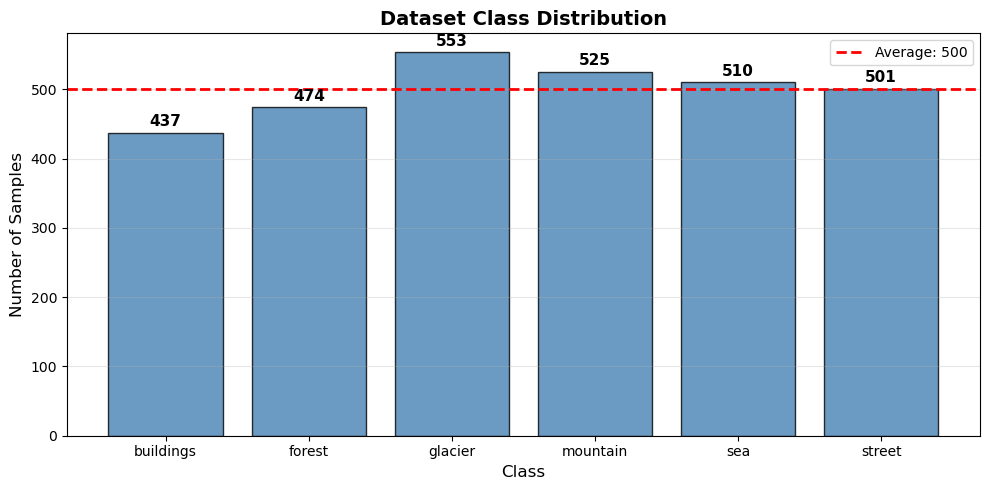


✅ Dataset information loaded successfully!


In [4]:
# Load dataset information using CountDataset utility
print("\U0001f50d Loading dataset information...")
dataset_info = CountDataset(DATASET_DIR)

# Extract class names and count
class_names = sorted([
    d for d in os.listdir(DATASET_DIR)
    if os.path.isdir(os.path.join(DATASET_DIR, d)) and not d.startswith('.')
])
NUM_CLASSES = len(class_names)

# Build class counts array (ordered by class name)
class_counts = np.array([dataset_info[cn]['samples'] for cn in class_names])
total_samples = int(dataset_info['total_samples'])

print(f"\n\U0001f4ca Class Distribution Analysis:")
print(f"   Total classes: {NUM_CLASSES}")
print(f"   Total samples: {total_samples:,}")
print(f"   Most populated class: {class_names[np.argmax(class_counts)]} ({class_counts.max():,} samples)")
print(f"   Least populated class: {class_names[np.argmin(class_counts)]} ({class_counts.min():,} samples)")
print(f"   Average per class: {class_counts.mean():.1f} samples")
print(f"   Imbalance ratio: {class_counts.max() / class_counts.min():.2f}x")

# Visualize class distribution
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(class_names, class_counts, color='steelblue', alpha=0.8, edgecolor='black')
ax.axhline(y=class_counts.mean(), color='red', linestyle='--', linewidth=2, label=f'Average: {class_counts.mean():.0f}')
ax.set_xlabel('Class', fontsize=12)
ax.set_ylabel('Number of Samples', fontsize=12)
ax.set_title('Dataset Class Distribution', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Add count labels on bars
for bar, count in zip(bars, class_counts):
    ax.text(bar.get_x() + bar.get_width() / 2., bar.get_height() + 5,
            f'{count}', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

print("\n\u2705 Dataset information loaded successfully!")

### Visualize Sample Images from Dataset

Display sample landscape images from each class to understand the data better.

🖼️  Displaying sample landscape images from dataset...


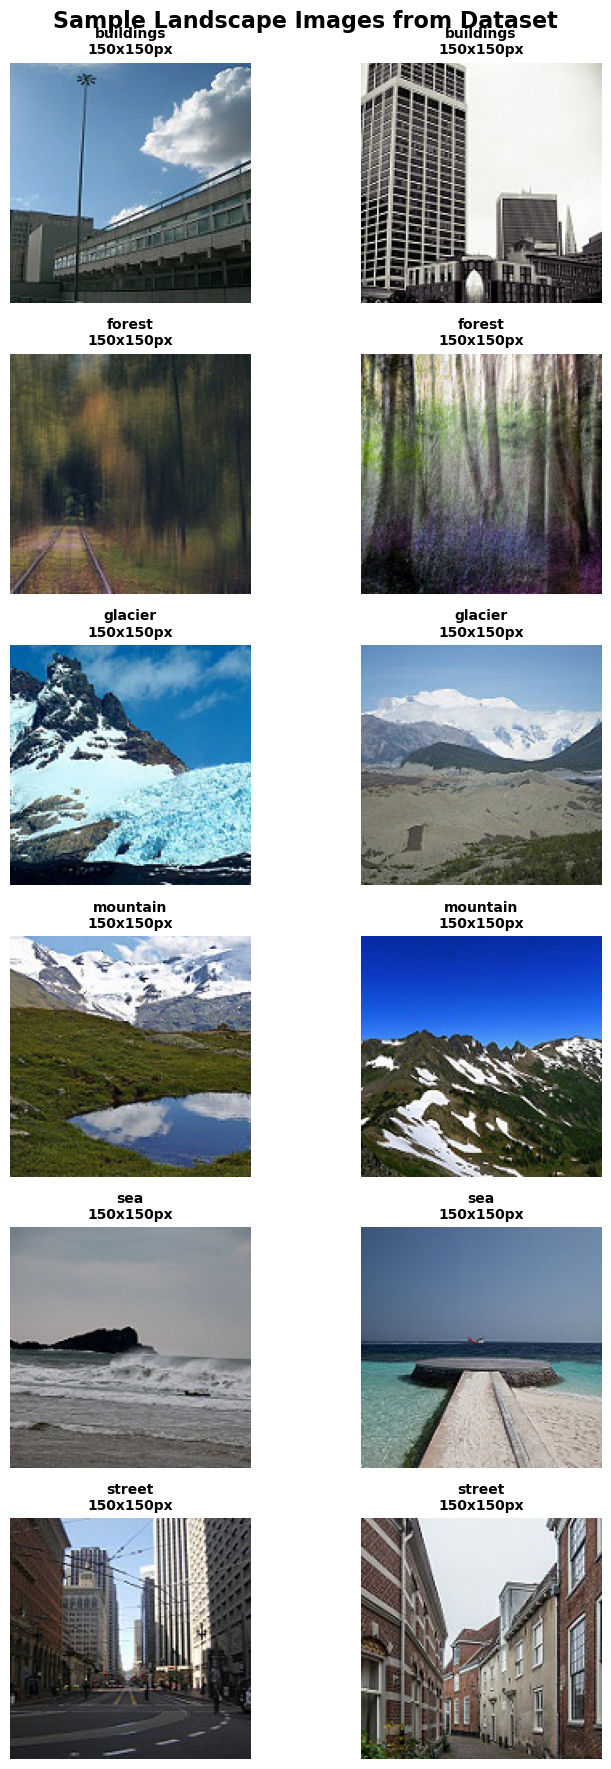

✅ Sample visualization complete!


In [5]:
# Visualize random samples from each class
print("\U0001f5bc\ufe0f  Displaying sample landscape images from dataset...")

num_samples_per_class = 2
fig, axes = plt.subplots(NUM_CLASSES, num_samples_per_class, figsize=(8, 3 * NUM_CLASSES))

for row, class_name in enumerate(class_names):
    class_dir = os.path.join(DATASET_DIR, class_name)
    image_files = [f for f in os.listdir(class_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    selected = random.sample(image_files, min(num_samples_per_class, len(image_files)))
    
    for col, img_file in enumerate(selected):
        img_path = os.path.join(class_dir, img_file)
        img = Image.open(img_path).convert('RGB')
        w, h = img.size
        
        axes[row, col].imshow(img)
        axes[row, col].axis('off')
        axes[row, col].set_title(f'{class_name}\n{w}x{h}px', fontsize=10, fontweight='bold')

plt.suptitle('Sample Landscape Images from Dataset', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\u2705 Sample visualization complete!")

### Data Augmentation & Transforms

Define transforms for training (with configurable augmentation) and validation/test sets.
Landscape-specific augmentations optimized for scene recognition.

In [6]:
if USE_AUGMENTATION:
    # Build augmentation list dynamically based on AUGMENTATION_OPTIONS
    augmentation_transforms = []
    applied_augmentations = []
    
    if AUGMENTATION_OPTIONS.get("random_resized_crop", False):
        augmentation_transforms.append(
            transforms.RandomResizedCrop((IMG_HEIGHT, IMG_WIDTH), scale=RESIZED_CROP_SCALE)
        )
        applied_augmentations.append(f"Random Resized Crop: scale={RESIZED_CROP_SCALE}")
    else:
        augmentation_transforms.append(transforms.Resize((IMG_HEIGHT, IMG_WIDTH)))
    
    if AUGMENTATION_OPTIONS.get("random_horizontal_flip", False):
        augmentation_transforms.append(transforms.RandomHorizontalFlip(p=0.5))
        applied_augmentations.append("Random Horizontal Flip: p=0.5")
    
    if AUGMENTATION_OPTIONS.get("random_rotation", False):
        augmentation_transforms.append(transforms.RandomRotation(ROTATION_DEGREES))
        applied_augmentations.append(f"Random Rotation: \u00b1{ROTATION_DEGREES}\u00b0")
    
    if AUGMENTATION_OPTIONS.get("random_affine", False):
        augmentation_transforms.append(
            transforms.RandomAffine(degrees=0, translate=AFFINE_TRANSLATE, scale=AFFINE_SCALE)
        )
        applied_augmentations.append(f"Random Affine: translate={AFFINE_TRANSLATE}, scale={AFFINE_SCALE}")
    
    if AUGMENTATION_OPTIONS.get("color_jitter", False):
        augmentation_transforms.append(
            transforms.ColorJitter(
                brightness=COLOR_BRIGHTNESS, contrast=COLOR_CONTRAST,
                saturation=COLOR_SATURATION, hue=COLOR_HUE
            )
        )
        applied_augmentations.append(f"Color Jitter: brightness={COLOR_BRIGHTNESS}, contrast={COLOR_CONTRAST}, saturation={COLOR_SATURATION}, hue={COLOR_HUE}")
    
    if AUGMENTATION_OPTIONS.get("random_perspective", False):
        augmentation_transforms.append(
            transforms.RandomPerspective(distortion_scale=PERSPECTIVE_DISTORTION, p=PERSPECTIVE_PROB)
        )
        applied_augmentations.append(f"Random Perspective: distortion={PERSPECTIVE_DISTORTION}, p={PERSPECTIVE_PROB}")
    
    if AUGMENTATION_OPTIONS.get("gaussian_blur", False):
        augmentation_transforms.append(
            transforms.RandomApply([transforms.GaussianBlur(kernel_size=GAUSSIAN_BLUR_KERNEL)], p=GAUSSIAN_BLUR_PROB)
        )
        applied_augmentations.append(f"Gaussian Blur: kernel={GAUSSIAN_BLUR_KERNEL}, p={GAUSSIAN_BLUR_PROB}")
    
    # ToTensor and Normalize always applied
    augmentation_transforms.append(transforms.ToTensor())
    augmentation_transforms.append(transforms.Normalize(mean=NORMALIZE_MEAN, std=NORMALIZE_STD))
    
    if AUGMENTATION_OPTIONS.get("random_erasing", False):
        augmentation_transforms.append(
            transforms.RandomErasing(p=ERASING_PROB, scale=ERASING_SCALE)
        )
        applied_augmentations.append(f"Random Erasing: p={ERASING_PROB}, scale={ERASING_SCALE}")
    
    train_transforms = transforms.Compose(augmentation_transforms)
    
    print("\u2705 Training augmentation ENABLED")
    print(f"   Active augmentations ({len(applied_augmentations)}):")
    for aug in applied_augmentations:
        print(f"   - {aug}")
else:
    # No augmentation
    train_transforms = transforms.Compose([
        transforms.Resize((IMG_HEIGHT, IMG_WIDTH)),
        transforms.ToTensor(),
        transforms.Normalize(mean=NORMALIZE_MEAN, std=NORMALIZE_STD)
    ])
    print("\u26a0\ufe0f  Training augmentation DISABLED")

# Validation and test transforms (no augmentation)
val_test_transforms = transforms.Compose([
    transforms.Resize((IMG_HEIGHT, IMG_WIDTH)),
    transforms.ToTensor(),
    transforms.Normalize(mean=NORMALIZE_MEAN, std=NORMALIZE_STD)
])

print(f"\n\u2705 Transforms defined successfully!")
print(f"   Target size: {IMG_HEIGHT}x{IMG_WIDTH}")
print(f"   Normalization: Mean={NORMALIZE_MEAN}, Std={NORMALIZE_STD}")

✅ Training augmentation ENABLED
   Active augmentations (8):
   - Random Resized Crop: scale=(0.8, 1.0)
   - Random Horizontal Flip: p=0.5
   - Random Rotation: ±20°
   - Random Affine: translate=(0.1, 0.1), scale=(0.85, 1.15)
   - Color Jitter: brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1
   - Random Perspective: distortion=0.2, p=0.5
   - Gaussian Blur: kernel=(3, 3), p=0.3
   - Random Erasing: p=0.1, scale=(0.02, 0.1)

✅ Transforms defined successfully!
   Target size: 224x224
   Normalization: Mean=[0.485, 0.456, 0.406], Std=[0.229, 0.224, 0.225]


### Load Dataset & Create Train/Val/Test Splits

Load the folder-based dataset using ImageFolder and split into train, validation, and test sets.

In [7]:
# Load the full dataset with no transforms initially (will assign after split)
print("\U0001f4c2 Loading landscape dataset...")
full_dataset = datasets.ImageFolder(root=DATASET_DIR)

# Verify class mapping
print(f"\n\U0001f4ca Class to index mapping:")
for cls_name, cls_idx in sorted(full_dataset.class_to_idx.items(), key=lambda x: x[1]):
    print(f"   {cls_idx}: {cls_name}")

NUM_CLASSES = len(full_dataset.classes)
total_samples = len(full_dataset)

# Calculate split sizes
train_size = int(TRAIN_SPLIT * total_samples)
val_size = int(VAL_SPLIT * total_samples)
test_size = total_samples - train_size - val_size  # Remainder goes to test

print(f"\n\u2705 Dataset loaded: {total_samples:,} total samples")
print(f"   Classes: {NUM_CLASSES}")

# Split dataset
train_subset, val_subset, test_subset = random_split(
    full_dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(SEED)
)

print(f"\n\u2705 Data split completed:")
print(f"   \U0001f539 Train: {train_size:,} samples ({TRAIN_SPLIT*100:.0f}%)")
print(f"   \U0001f539 Validation: {val_size:,} samples ({VAL_SPLIT*100:.0f}%)")
print(f"   \U0001f539 Test: {test_size:,} samples ({TEST_SPLIT*100:.0f}%)")

# Create wrapper datasets with correct transforms
class TransformSubset(torch.utils.data.Dataset):
    """Wraps a Subset with a specific transform."""
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform
    
    def __getitem__(self, idx):
        img, label = self.subset[idx]
        if self.transform:
            img = self.transform(img)
        return img, label
    
    def __len__(self):
        return len(self.subset)

train_dataset = TransformSubset(train_subset, train_transforms)
val_dataset = TransformSubset(val_subset, val_test_transforms)
test_dataset = TransformSubset(test_subset, val_test_transforms)

print(f"\n\u2705 Transforms assigned:")
print(f"   Train: Augmentation {'ENABLED' if USE_AUGMENTATION else 'DISABLED'}")
print(f"   Validation/Test: No augmentation")

📂 Loading landscape dataset...

📊 Class to index mapping:
   0: buildings
   1: forest
   2: glacier
   3: mountain
   4: sea
   5: street

✅ Dataset loaded: 3,000 total samples
   Classes: 6

✅ Data split completed:
   🔹 Train: 2,100 samples (70%)
   🔹 Validation: 450 samples (15%)
   🔹 Test: 450 samples (15%)

✅ Transforms assigned:
   Train: Augmentation ENABLED
   Validation/Test: No augmentation


### Compute Class Weights for Imbalanced Data

Calculate class weights to handle class imbalance in the dataset.
This helps the model learn minority classes better.

In [8]:
# Get all labels from the full dataset
all_targets = [full_dataset.targets[i] for i in train_subset.indices]

# Count per-class samples in training set
train_class_counts = Counter(all_targets)
train_class_counts_array = np.array([train_class_counts[i] for i in range(NUM_CLASSES)])

print(f"\U0001f4ca Training set class distribution:")
print(f"   Total classes: {NUM_CLASSES}")
for i, cn in enumerate(class_names):
    print(f"   {cn}: {train_class_counts_array[i]:,} samples")
print(f"   Most populated: {class_names[np.argmax(train_class_counts_array)]} ({train_class_counts_array.max():,})")
print(f"   Least populated: {class_names[np.argmin(train_class_counts_array)]} ({train_class_counts_array.min():,})")
print(f"   Imbalance ratio: {train_class_counts_array.max() / train_class_counts_array.min():.2f}x")

# Compute class weights (inverse frequency)
class_weights = 1.0 / train_class_counts_array.astype(np.float64)
class_weights = class_weights / class_weights.sum() * NUM_CLASSES  # Normalize so weights average to 1.0

print(f"\n\U0001f4d0 Class weights computed (inverse frequency):")
for i, cn in enumerate(class_names):
    print(f"   {cn}: {class_weights[i]:.4f}")
print(f"   Min weight: {class_weights.min():.4f}")
print(f"   Max weight: {class_weights.max():.4f}")
print(f"   Weight ratio: {class_weights.max() / class_weights.min():.2f}x")

# Create sample weights for WeightedRandomSampler
if USE_WEIGHTED_SAMPLER:
    sample_weights = [class_weights[label] for label in all_targets]
    print(f"\n\u2705 Weighted sampler initialized for {len(sample_weights):,} training samples")
else:
    sample_weights = None
    print("\n\u26a0\ufe0f  Weighted sampler DISABLED")

📊 Training set class distribution:
   Total classes: 6
   buildings: 309 samples
   forest: 329 samples
   glacier: 382 samples
   mountain: 375 samples
   sea: 353 samples
   street: 352 samples
   Most populated: glacier (382)
   Least populated: buildings (309)
   Imbalance ratio: 1.24x

📐 Class weights computed (inverse frequency):
   buildings: 1.1267
   forest: 1.0582
   glacier: 0.9114
   mountain: 0.9284
   sea: 0.9863
   street: 0.9891
   Min weight: 0.9114
   Max weight: 1.1267
   Weight ratio: 1.24x

✅ Weighted sampler initialized for 2,100 training samples


### Create DataLoaders

Initialize PyTorch DataLoaders with appropriate batch size and sampling strategy.

In [9]:
# Create training DataLoader
if USE_WEIGHTED_SAMPLER:
    sampler = WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(sample_weights),
        replacement=True
    )
    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        sampler=sampler,
        num_workers=0,  # Set to 0 for Windows compatibility
        pin_memory=True if torch.cuda.is_available() else False
    )
    print(f"\u2705 Train DataLoader: {len(train_dataset):,} samples with WeightedRandomSampler")
else:
    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=0,
        pin_memory=True if torch.cuda.is_available() else False
    )
    print(f"\u2705 Train DataLoader: {len(train_dataset):,} samples with shuffle=True")

# Create validation DataLoader
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True if torch.cuda.is_available() else False
)
print(f"\u2705 Validation DataLoader: {len(val_dataset):,} samples")

# Create test DataLoader
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True if torch.cuda.is_available() else False
)
print(f"\u2705 Test DataLoader: {len(test_dataset):,} samples")

print(f"\n\U0001f4e6 Batch configuration:")
print(f"   Batch size: {BATCH_SIZE}")
print(f"   Train batches: {len(train_loader)}")
print(f"   Validation batches: {len(val_loader)}")
print(f"   Test batches: {len(test_loader)}")

✅ Train DataLoader: 2,100 samples with WeightedRandomSampler
✅ Validation DataLoader: 450 samples
✅ Test DataLoader: 450 samples

📦 Batch configuration:
   Batch size: 32
   Train batches: 66
   Validation batches: 15
   Test batches: 15


#### PRINT SUMMARY

In [10]:
print("\n" + "="*80)
print("\U0001f4ca PREPROCESSING SUMMARY")
print("="*80)
print(f"{'Dataset:':<30} Landscape (Intel Image Classification)")
print(f"{'Total Classes:':<30} {NUM_CLASSES}")
print(f"{'Class Names:':<30} {', '.join(class_names)}")
print(f"{'Training Samples:':<30} {train_size:,}")
print(f"{'Validation Samples:':<30} {val_size:,}")
print(f"{'Test Samples:':<30} {test_size:,}")
print(f"{'Total Samples:':<30} {total_samples:,}")
print(f"\n{'Image Processing:':<30}")
print(f"  {'- Target Size:':<28} {IMG_HEIGHT}x{IMG_WIDTH} pixels")
print(f"  {'- Normalization:':<28} {'ImageNet' if USE_IMAGENET_NORM else 'Custom'}")
print(f"\n{'Augmentation:':<30} {'ENABLED' if USE_AUGMENTATION else 'DISABLED'}")
if USE_AUGMENTATION:
    active = [k for k, v in AUGMENTATION_OPTIONS.items() if v]
    for aug_name in active:
        print(f"  - {aug_name}")
print(f"\n{'Class Balancing:':<30}")
print(f"  {'- Weighted Sampling:':<28} {'ENABLED' if USE_WEIGHTED_SAMPLER else 'DISABLED'}")
print(f"  {'- Class Imbalance Ratio:':<28} {train_class_counts_array.max() / train_class_counts_array.min():.2f}x")
print(f"\n{'Batch Configuration:':<30}")
print(f"  {'- Batch Size:':<28} {BATCH_SIZE}")
print(f"  {'- Train Batches/Epoch:':<28} {len(train_loader)}")
print(f"  {'- Val Batches/Epoch:':<28} {len(val_loader)}")
print(f"  {'- Test Batches:':<28} {len(test_loader)}")
print("="*80)
print("\u2705 Preprocessing complete! Ready for model training.\n")


📊 PREPROCESSING SUMMARY
Dataset:                       Landscape (Intel Image Classification)
Total Classes:                 6
Class Names:                   buildings, forest, glacier, mountain, sea, street
Training Samples:              2,100
Validation Samples:            450
Test Samples:                  450
Total Samples:                 3,000

Image Processing:             
  - Target Size:               224x224 pixels
  - Normalization:             ImageNet

Augmentation:                  ENABLED
  - random_horizontal_flip
  - random_rotation
  - random_affine
  - color_jitter
  - random_perspective
  - random_resized_crop
  - gaussian_blur
  - random_erasing

Class Balancing:              
  - Weighted Sampling:         ENABLED
  - Class Imbalance Ratio:     1.24x

Batch Configuration:          
  - Batch Size:                32
  - Train Batches/Epoch:       66
  - Val Batches/Epoch:         15
  - Test Batches:              15
✅ Preprocessing complete! Ready for model train

#### MODEL TRAINING KEY VARIABLES

In [11]:
# ============================
# MODEL TRAINING CONFIGURATION
# ============================

# Training hyperparameters
LEARNING_RATE = 1e-4          # Initial learning rate for AdamW
MAX_EPOCHS = 30               # Maximum training epochs
WEIGHT_DECAY = 1e-4           # L2 regularization to prevent overfitting
DROPOUT_RATE = 0.4            # Dropout in classifier head

# Early stopping
EARLY_STOPPING_PATIENCE = 10  # Stop if no improvement for 10 epochs
LABEL_SMOOTHING = 0.1         # Label smoothing for better generalisation (reduces overconfidence)

# Gradient clipping
MAX_GRAD_NORM = 1.0           # Prevent exploding gradients

# Cosine Annealing Warm Restarts scheduler config
COSINE_T_0 = 10               # Number of epochs for the first restart cycle
COSINE_T_MULT = 2             # Factor to increase cycle length after each restart
COSINE_ETA_MIN = 1e-7         # Minimum learning rate

# Training history dictionary (global)
history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": [],
    "train_top5_acc": [],
    "val_top5_acc": [],
    "learning_rates": [],
    "worst_class_acc": [],
    "worst_class_name": []
}

print("\U0001f3af Training Configuration:")
print(f"   Model: {MODEL_ARCH.upper()}")
print(f"   Learning Rate: {LEARNING_RATE}")
print(f"   Weight Decay: {WEIGHT_DECAY}")
print(f"   Dropout Rate: {DROPOUT_RATE}")
print(f"   Max Epochs: {MAX_EPOCHS}")
print(f"   Early Stopping Patience: {EARLY_STOPPING_PATIENCE}")
print(f"   Gradient Clipping: {MAX_GRAD_NORM}")
print(f"   Label Smoothing: {LABEL_SMOOTHING}")
print(f"   LR Scheduler: CosineAnnealingWarmRestarts (T_0={COSINE_T_0}, T_mult={COSINE_T_MULT}, eta_min={COSINE_ETA_MIN})")
print(f"   Classes: {NUM_CLASSES}")

🎯 Training Configuration:
   Model: RESNET50
   Learning Rate: 0.0001
   Weight Decay: 0.0001
   Dropout Rate: 0.4
   Max Epochs: 30
   Early Stopping Patience: 10
   Gradient Clipping: 1.0
   LR Scheduler: CosineAnnealingWarmRestarts (T_0=10, T_mult=2, eta_min=1e-07)
   Classes: 6


### Load Pretrained Model Architecture

In [12]:
# Load pretrained ResNet50 model
CheckCUDA()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
print("\n\u2705 Pre-trained ResNet50 loaded (weights: IMAGENET1K_V2)")

# Replace classifier head with dropout
in_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(DROPOUT_RATE),
    nn.Linear(in_features, NUM_CLASSES)
)
print(f"\u2705 Classifier replaced: {in_features} \u2192 Dropout({DROPOUT_RATE}) \u2192 {NUM_CLASSES} classes")

# Move model to GPU
model = model.to(device)
print(f"\u2705 Model moved to device: {device.type.upper()}")
print(f"\U0001f4ca Model parameters: {sum(p.numel() for p in model.parameters()):,}")


⚡ CUDA / PYTORCH INFORMATION
✅ CUDA Available       : True
   • PyTorch CUDA Ver.  : 12.4
   • PyTorch Version    : 2.6.0+cu124
✅ cuDNN Version        : 90100
   • CUDA Device Count  : 1
   • Device 0 Name     : NVIDIA GeForce RTX 2060


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to C:\Users\K1taru/.cache\torch\hub\checkpoints\resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [00:34<00:00, 2.99MB/s]



✅ Pre-trained ResNet50 loaded (weights: IMAGENET1K_V2)
✅ Classifier replaced: 2048 → Dropout(0.4) → 6 classes
✅ Model moved to device: CUDA
📊 Model parameters: 23,520,326


#### LOSS & OPTIMIZER

In [13]:
# Loss function with class weights
class_weights_tensor = torch.FloatTensor(class_weights).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor, label_smoothing=LABEL_SMOOTHING)
print(f"\u2705 Loss function: CrossEntropyLoss with class weights")

# AdamW optimizer with weight decay (L2 regularization)
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
print(f"\u2705 Optimizer: AdamW (lr={LEARNING_RATE}, weight_decay={WEIGHT_DECAY})")

# Learning rate scheduler - CosineAnnealingWarmRestarts
# Best for training from pretrained models: smooth LR decay with periodic warm restarts
# to escape local minima and explore different regions of the loss landscape
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer,
    T_0=COSINE_T_0,
    T_mult=COSINE_T_MULT,
    eta_min=COSINE_ETA_MIN
)
print(f"\u2705 LR Scheduler: CosineAnnealingWarmRestarts (T_0={COSINE_T_0}, T_mult={COSINE_T_MULT}, eta_min={COSINE_ETA_MIN})")

✅ Loss function: CrossEntropyLoss with class weights
✅ Optimizer: AdamW (lr=0.0001, weight_decay=0.0001)
✅ LR Scheduler: CosineAnnealingWarmRestarts (T_0=10, T_mult=2, eta_min=1e-07)


#### Model Summary

In [14]:
print("\n" + "="*60)
print("\U0001f680 MODEL SETUP COMPLETE")
print("="*60)
print(f"{'Architecture:':<25} {MODEL_ARCH.upper()}")
print(f"{'Input Size:':<25} {IMG_HEIGHT}x{IMG_WIDTH}")
print(f"{'Output Classes:':<25} {NUM_CLASSES} ({', '.join(class_names)})")
print(f"{'Total Parameters:':<25} {sum(p.numel() for p in model.parameters()):,}")
print(f"{'Trainable Parameters:':<25} {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print(f"\n{'Training Settings:':<25}")
print(f"{'  Learning Rate:':<25} {LEARNING_RATE}")
print(f"{'  Weight Decay:':<25} {WEIGHT_DECAY}")
print(f"{'  Dropout Rate:':<25} {DROPOUT_RATE}")
print(f"{'  Max Epochs:':<25} {MAX_EPOCHS}")
print(f"{'  Early Stop Patience:':<25} {EARLY_STOPPING_PATIENCE}")
print(f"{'  Device:':<25} {device.type.upper()}")
print(f"{'  Loss Function:':<25} CrossEntropyLoss (weighted)")
print(f"{'  Optimizer:':<25} AdamW")
print(f"{'  LR Scheduler:':<25} CosineAnnealingWarmRestarts")
print("="*60 + "\n")


🚀 MODEL SETUP COMPLETE
Architecture:             RESNET50
Input Size:               224x224
Output Classes:           6 (buildings, forest, glacier, mountain, sea, street)
Total Parameters:         23,520,326
Trainable Parameters:     23,520,326

Training Settings:       
  Learning Rate:          0.0001
  Weight Decay:           0.0001
  Dropout Rate:           0.4
  Max Epochs:             30
  Early Stop Patience:    10
  Device:                 CUDA
  Loss Function:          CrossEntropyLoss (weighted)
  Optimizer:              AdamW
  LR Scheduler:           CosineAnnealingWarmRestarts



### TRAINING & VALIDATION LOOP

In [15]:
def calculate_top_k_accuracy(outputs, labels, k=5):
    """Calculate top-k accuracy."""
    # Clamp k to number of classes
    k = min(k, outputs.size(1))
    _, topk_preds = outputs.topk(k, dim=1, largest=True, sorted=True)
    correct = topk_preds.eq(labels.view(-1, 1).expand_as(topk_preds))
    return correct.sum().item()


def train_model(model, criterion, optimizer, scheduler, num_epochs=MAX_EPOCHS):
    """
    Training loop with:
    - Top-5 accuracy tracking
    - Early stopping
    - Gradient clipping
    - Learning rate tracking
    - Overfitting detection
    - CosineAnnealingWarmRestarts scheduler
    """
    best_val_acc = 0.0
    best_epoch = 0
    best_model_wts = copy.deepcopy(model.state_dict())
    epochs_without_improvement = 0
    
    print("\n" + "="*80)
    print("\U0001f3af STARTING TRAINING")
    print("="*80)

    for epoch in range(num_epochs):
        print(f"\n{'='*80}")
        print(f"\U0001f4c6 Epoch {epoch+1}/{num_epochs}")
        print(f"{'='*80}")
        print(f"Learning Rate: {optimizer.param_groups[0]['lr']:.2e}")
        
        epoch_metrics = {}
        val_preds_epoch = []
        val_labels_epoch = []

        # TRAIN & VALIDATION LOOP
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
                dataloader = train_loader
            else:
                model.eval()
                dataloader = val_loader

            running_loss = 0.0
            running_corrects = 0
            running_top5_corrects = 0
            total_samples = 0

            # Progress bar
            loop = tqdm(
                dataloader,
                desc=f"{'\U0001f525 TRAIN' if phase == 'train' else '\u2705 VAL  '}",
                leave=False,
                ncols=100
            )

            for inputs, labels in loop:
                inputs = inputs.to(device)
                labels = labels.to(device)
                batch_size = inputs.size(0)
                total_samples += batch_size

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        # Gradient clipping to prevent exploding gradients
                        torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
                        optimizer.step()

                # Statistics
                running_loss += loss.item() * batch_size
                running_corrects += torch.sum(preds == labels.data).item()
                running_top5_corrects += calculate_top_k_accuracy(outputs, labels, k=5)

                if phase == 'val':
                    val_preds_epoch.extend(preds.cpu().numpy())
                    val_labels_epoch.extend(labels.cpu().numpy())

                # Update progress bar
                current_acc = running_corrects / total_samples
                loop.set_postfix({
                    'loss': f'{loss.item():.4f}',
                    'acc': f'{current_acc:.4f}'
                })

            # Calculate epoch metrics
            epoch_loss = running_loss / total_samples
            epoch_acc = running_corrects / total_samples
            epoch_top5_acc = running_top5_corrects / total_samples

            # Store metrics
            epoch_metrics[f'{phase}_loss'] = epoch_loss
            epoch_metrics[f'{phase}_acc'] = epoch_acc
            epoch_metrics[f'{phase}_top5_acc'] = epoch_top5_acc
            
            # Print epoch results
            print(f"{phase.upper():>5} | Loss: {epoch_loss:.4f} | "
                  f"Acc: {epoch_acc*100:>6.2f}% | Top-5: {epoch_top5_acc*100:>6.2f}%")

            if phase == 'val':
                _vp = np.array(val_preds_epoch)
                _vl = np.array(val_labels_epoch)
                _per_cls = np.array([
                    (_vp[_vl == c] == c).sum() / max((_vl == c).sum(), 1)
                    for c in range(NUM_CLASSES)
                ])
                worst_idx = int(np.argmin(_per_cls))
                worst_name = class_names[worst_idx]
                worst_acc  = _per_cls[worst_idx]
                print(f"  VAL  | Worst Class : {worst_name} ({worst_acc*100:.2f}% accuracy)")

        # Step the CosineAnnealingWarmRestarts scheduler (epoch-based)
        scheduler.step()
        current_lr = optimizer.param_groups[0]['lr']
        
        # Save metrics to history
        history["train_loss"].append(epoch_metrics['train_loss'])
        history["val_loss"].append(epoch_metrics['val_loss'])
        history["train_acc"].append(epoch_metrics['train_acc'])
        history["val_acc"].append(epoch_metrics['val_acc'])
        history["train_top5_acc"].append(epoch_metrics['train_top5_acc'])
        history["val_top5_acc"].append(epoch_metrics['val_top5_acc'])
        history["learning_rates"].append(current_lr)
        history["worst_class_acc"].append(worst_acc)
        history["worst_class_name"].append(worst_name)
        
        # Check for overfitting
        loss_gap = epoch_metrics['train_loss'] - epoch_metrics['val_loss']
        acc_gap = epoch_metrics['train_acc'] - epoch_metrics['val_acc']
        
        if loss_gap < -0.1 or acc_gap > 0.1:
            print(f"\u26a0\ufe0f  Overfitting detected: Train-Val gap = {acc_gap*100:.2f}% (acc), {loss_gap:.4f} (loss)")
        
        # Save best model
        if epoch_metrics['val_acc'] > best_val_acc:
            best_val_acc = epoch_metrics['val_acc']
            best_epoch = epoch + 1
            best_model_wts = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0
            print(f"\u2728 New best validation accuracy: {best_val_acc*100:.2f}%")
        else:
            epochs_without_improvement += 1
            print(f"\U0001f4ca No improvement for {epochs_without_improvement} epoch(s)")
        
        # Early stopping
        if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
            print(f"\n\U0001f6d1 Early stopping triggered after {epoch+1} epochs")
            print(f"   Best validation accuracy: {best_val_acc*100:.2f}% at epoch {best_epoch}")
            break

    print("\n" + "="*80)
    print(f"\u2705 TRAINING COMPLETE")
    print(f"   Best Epoch: {best_epoch}")
    print(f"   Best Validation Accuracy: {best_val_acc*100:.2f}%")
    print("="*80 + "\n")
    
    model.load_state_dict(best_model_wts)
    return model, best_epoch, best_val_acc

CheckGPUBrief()

🟢 GPU: NVIDIA GeForce RTX 2060 | 💾 VRAM: 6.00 GB
🧠 PyTorch: 2.6.0+cu124 | 🧰 cuDNN: 90100


#### TRAIN THE MODEL & SAVE THE TRAINED MODEL

---

## Training Instructions

### Model: ResNet50

**Training Features:**
- Early stopping (patience=10 epochs)
- Overfitting detection and warnings
- CosineAnnealingWarmRestarts learning rate scheduler
- Gradient clipping
- Top-1 and Top-5 accuracy tracking
- Class-weighted loss for imbalanced data
- Dropout regularization
- Configurable data augmentation

### File Naming Examples:
- `Landscape_resnet50_E18_VAL92.45.pth` - ResNet50, epoch 18, 92.45% val acc

---

In [16]:
model, best_epoch, best_val_acc = train_model(model, criterion, optimizer, scheduler, num_epochs=MAX_EPOCHS)

# Generate model filename with architecture, epoch, and validation accuracy
model_name = f"Landscape_{MODEL_ARCH}_E{best_epoch}_VAL{best_val_acc * 100:.2f}.pth"
model_path = os.path.join(MODEL_SAVE_DIR, model_name)

# Save model state dict
torch.save({
    'epoch': best_epoch,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'val_acc': best_val_acc,
    'model_arch': MODEL_ARCH,
    'num_classes': NUM_CLASSES,
    'class_names': class_names,
    'history': history
}, model_path)

print(f"\n\U0001f4be Model saved successfully!")
print(f"   File: {model_name}")
print(f"   Path: {model_path}")
print(f"   Best Epoch: {best_epoch}")
print(f"   Validation Accuracy: {best_val_acc*100:.2f}%")


🎯 STARTING TRAINING

📆 Epoch 1/30
Learning Rate: 1.00e-04


TRAIN | Loss: 1.0180 | Acc:  69.57% | Top-5:  98.38%


  VAL | Loss: 0.2768 | Acc:  90.00% | Top-5: 100.00%
✨ New best validation accuracy: 90.00%

📆 Epoch 2/30
Learning Rate: 9.76e-05


TRAIN | Loss: 0.3240 | Acc:  89.14% | Top-5:  99.62%


  VAL | Loss: 0.2117 | Acc:  93.11% | Top-5:  99.78%
✨ New best validation accuracy: 93.11%

📆 Epoch 3/30
Learning Rate: 9.05e-05


...

  VAL | Loss: 0.2783 | Acc:  92.22% | Top-5: 100.00%
⚠️  Overfitting detected: Train-Val gap = 4.59% (acc), -0.1908 (loss)
📊 No improvement for 8 epoch(s)

📆 Epoch 16/30
Learning Rate: 8.54e-05


TRAIN | Loss: 0.0776 | Acc:  97.67% | Top-5: 100.00%


  VAL | Loss: 0.2072 | Acc:  94.67% | Top-5: 100.00%
⚠️  Overfitting detected: Train-Val gap = 3.00% (acc), -0.1297 (loss)
📊 No improvement for 9 epoch(s)

📆 Epoch 17/30
Learning Rate: 7.94e-05


TRAIN | Loss: 0.0721 | Acc:  98.00% | Top-5: 100.00%


  VAL | Loss: 0.2487 | Acc:  94.00% | Top-5: 100.00%
⚠️  Overfitting detected: Train-Val gap = 4.00% (acc), -0.1766 (loss)
📊 No improvement for 10 epoch(s)

🛑 Early stopping triggered after 17 epochs
   Best validation accuracy: 95.11% at epoch 7

✅ TRAINING COMPLETE
   Best Epoch: 7
   Best Validation Accuracy: 95.11%


💾 Model saved successfully!
   File: Landscape_resnet50_E7_VAL95.11.pth
   Path: ../models\Landscape_resnet50_E7_VAL95.11.pth
   Best Epoch: 7
   Validation Accuracy: 95.11%


#### Plotting Training Curves

C:\Users\K1taru\AppData\Local\Temp\ipykernel_7812\1578581463.py:42: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\K1taru\AppData\Local\Temp\ipykernel_7812\1578581463.py:42: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\K1taru\AppData\Local\Temp\ipykernel_7812\1578581463.py:42: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\K1taru\AppData\Local\Temp\ipykernel_7812\1578581463.py:42: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\K1taru\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\K1taru\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128

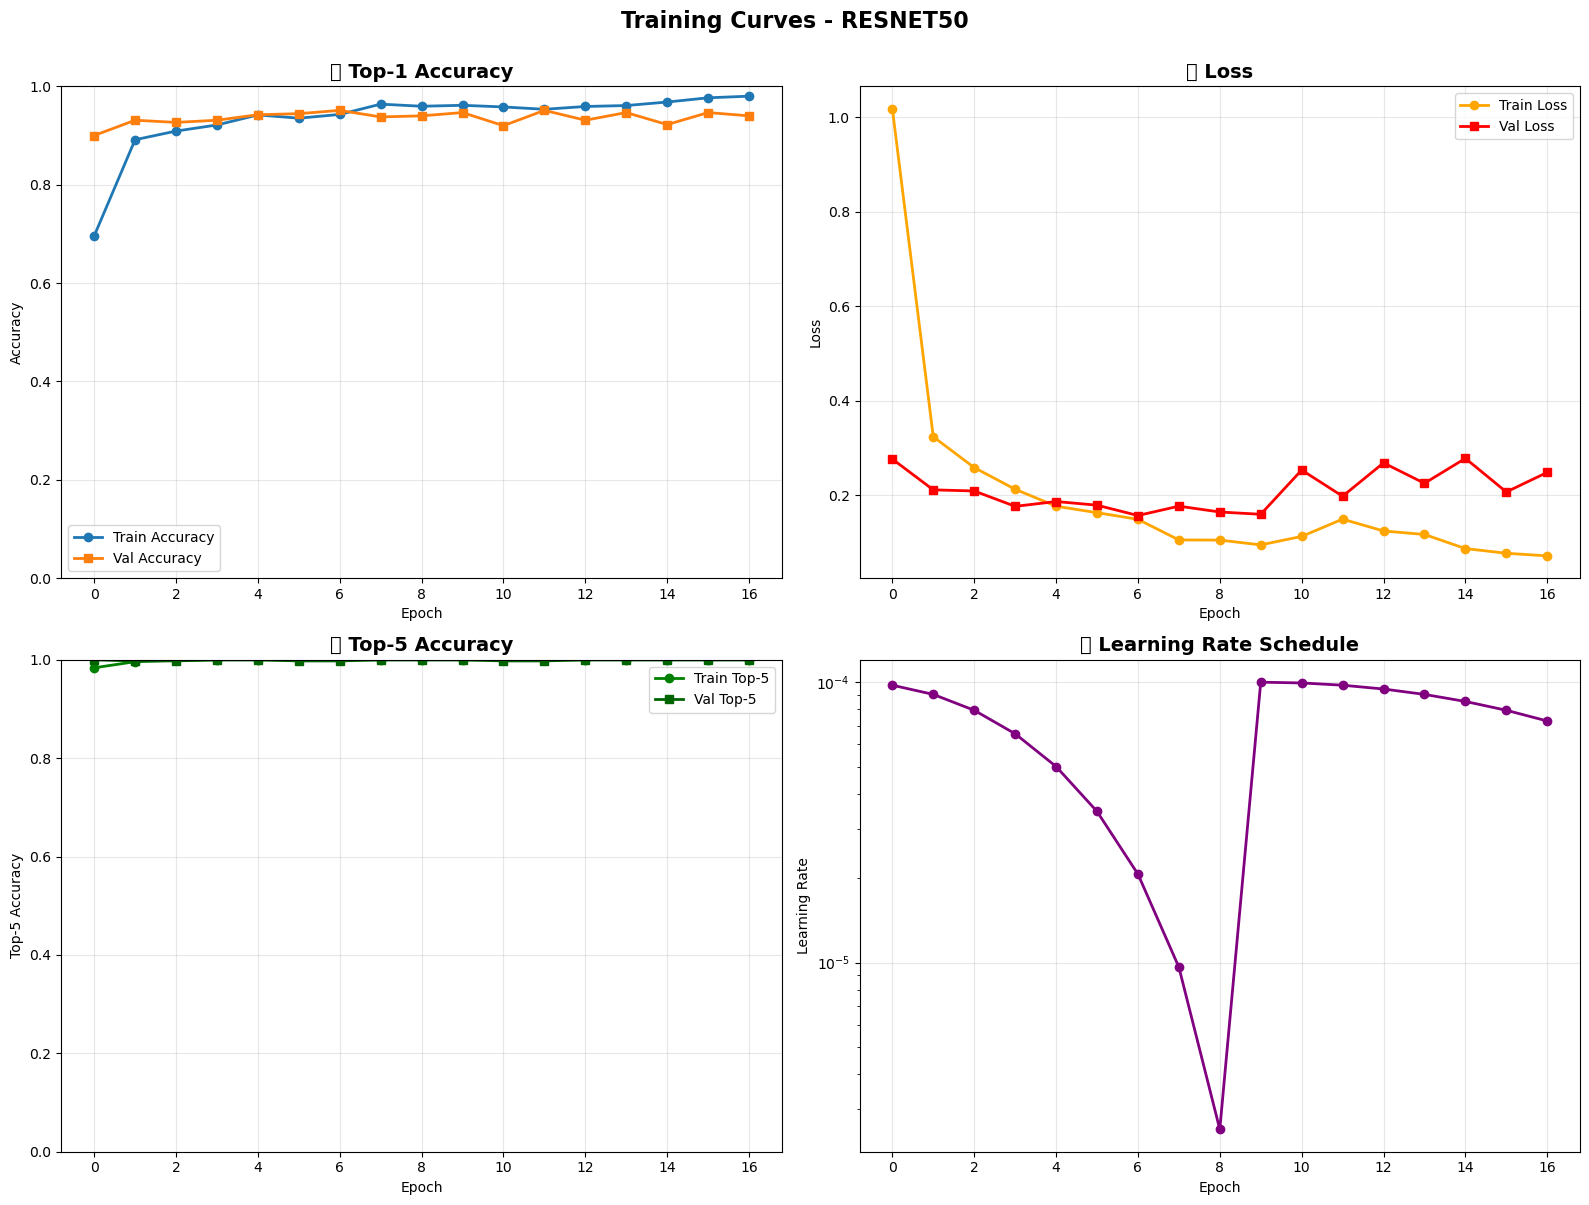

✅ Training curves displayed successfully!


In [17]:
# Create comprehensive training curves
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Top-1 Accuracy
axes[0, 0].plot(history["train_acc"], label="Train Accuracy", marker='o', linewidth=2)
axes[0, 0].plot(history["val_acc"], label="Val Accuracy", marker='s', linewidth=2)
axes[0, 0].set_title("\U0001f4c8 Top-1 Accuracy", fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Accuracy")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_ylim([0, 1])

# 2. Loss
axes[0, 1].plot(history["train_loss"], label="Train Loss", marker='o', linewidth=2, color='orange')
axes[0, 1].plot(history["val_loss"], label="Val Loss", marker='s', linewidth=2, color='red')
axes[0, 1].set_title("\U0001f4c9 Loss", fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Loss")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Top-5 Accuracy
axes[1, 0].plot(history["train_top5_acc"], label="Train Top-5", marker='o', linewidth=2, color='green')
axes[1, 0].plot(history["val_top5_acc"], label="Val Top-5", marker='s', linewidth=2, color='darkgreen')
axes[1, 0].set_title("\U0001f3af Top-5 Accuracy", fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("Top-5 Accuracy")
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_ylim([0, 1])

# 4. Learning Rate
axes[1, 1].plot(history["learning_rates"], marker='o', linewidth=2, color='purple')
axes[1, 1].set_title("\U0001f4ca Learning Rate Schedule", fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].set_ylabel("Learning Rate")
axes[1, 1].set_yscale('log')
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle(f"Training Curves - {MODEL_ARCH.upper()}", fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print("\u2705 Training curves displayed successfully!")

### Confusion Matrix

A confusion matrix provides a more detailed view of classification results.
It shows how many times the model correctly predicted each class versus how many times it confused it with another.

---

## POST-PROCESSING & EVALUATION

Comprehensive evaluation of the trained model on the test set.

🔍 Collecting model predictions on test set...
✅ Predictions collected successfully.

🎯 Overall Test Accuracy: 90.67%
🏆 Best performing class: sea (100.00% accuracy)
⚠️  Worst performing class: glacier (82.98% accuracy)
🔄 Most confused pair: glacier ↔ mountain (10 misclassifications)
⚖️  Balanced Accuracy: 91.02%
✅ Average confidence (correct predictions): 95.99%
❌ Average confidence (incorrect predictions): 85.60%



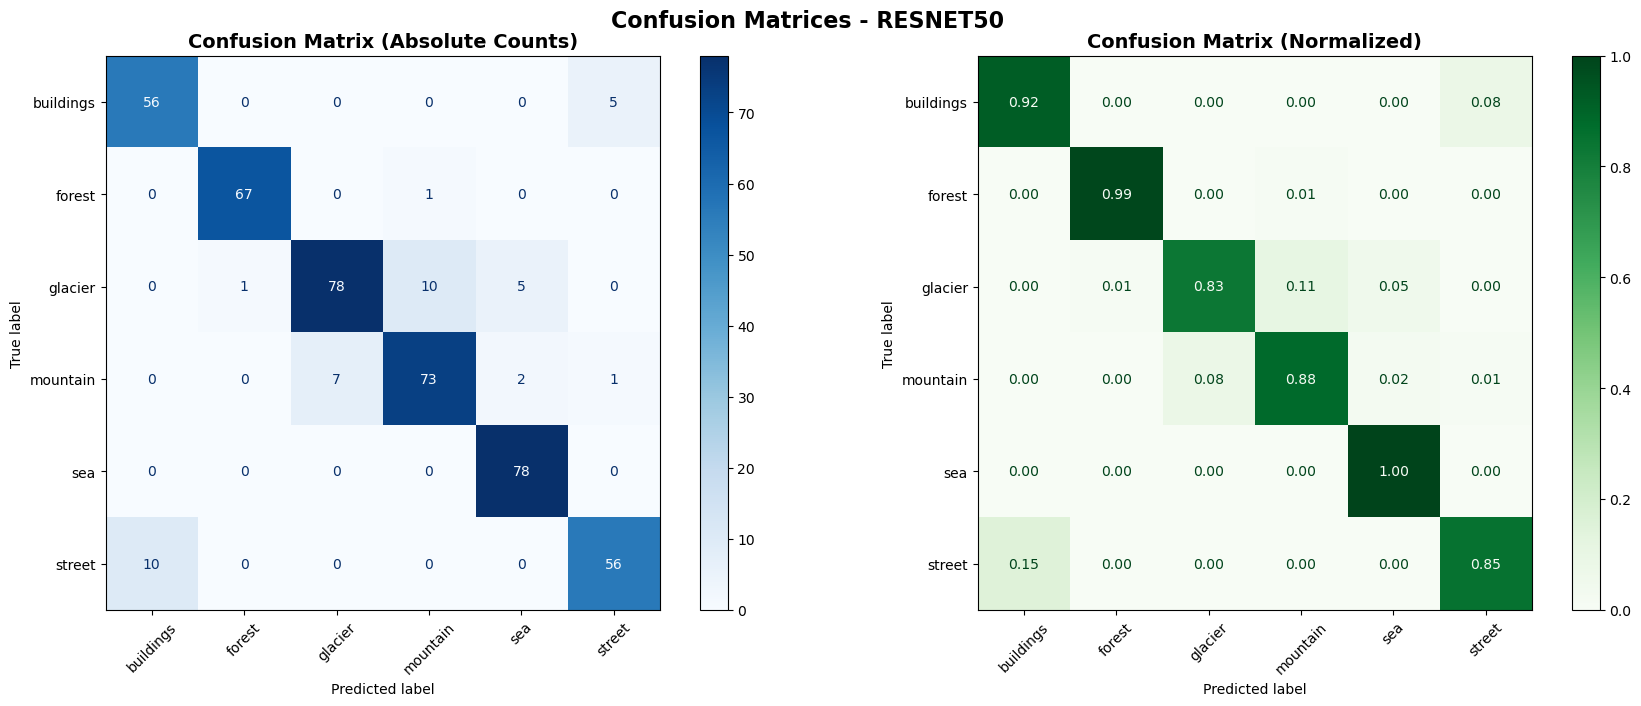


📊 Classification Report Summary:
              precision    recall  f1-score   support

   buildings      0.848     0.918     0.882        61
      forest      0.985     0.985     0.985        68
     glacier      0.918     0.830     0.872        94
    mountain      0.869     0.880     0.874        83
         sea      0.918     1.000     0.957        78
      street      0.903     0.848     0.875        66

    accuracy                          0.907       450
   macro avg      0.907     0.910     0.907       450
weighted avg      0.907     0.907     0.906       450



In [18]:
# Collect predictions on test set
print("\U0001f50d Collecting model predictions on test set...")
all_preds = []
all_labels = []
all_probs = []  # Store probabilities for confidence analysis

model.eval()
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model(inputs)
        probs = torch.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

print("\u2705 Predictions collected successfully.")

# Convert to numpy arrays
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

# Compute confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# Overall accuracy
accuracy = np.trace(cm) / np.sum(cm)
print(f"\n{'='*60}")
print(f"\U0001f3af Overall Test Accuracy: {accuracy * 100:.2f}%")
print(f"{'='*60}")

# Per-class accuracy
per_class_acc = cm.diagonal() / cm.sum(axis=1)
best_class_idx = np.argmax(per_class_acc)
worst_class_idx = np.argmin(per_class_acc)
print(f"\U0001f3c6 Best performing class: {class_names[best_class_idx]} ({per_class_acc[best_class_idx]*100:.2f}% accuracy)")
print(f"\u26a0\ufe0f  Worst performing class: {class_names[worst_class_idx]} ({per_class_acc[worst_class_idx]*100:.2f}% accuracy)")

# Most confused class pair
cm_copy = cm.copy().astype(float)
np.fill_diagonal(cm_copy, 0)
most_confused_idx = np.unravel_index(np.argmax(cm_copy), cm_copy.shape)
most_confused_value = int(cm_copy[most_confused_idx])
print(f"\U0001f504 Most confused pair: {class_names[most_confused_idx[0]]} \u2194 {class_names[most_confused_idx[1]]} ({most_confused_value} misclassifications)")

# Balanced accuracy
balanced_acc = balanced_accuracy_score(all_labels, all_preds)
print(f"\u2696\ufe0f  Balanced Accuracy: {balanced_acc * 100:.2f}%")

# Average confidence for correct and incorrect predictions
correct_mask = all_preds == all_labels
correct_confidences = [all_probs[i][all_preds[i]] for i in range(len(all_preds)) if correct_mask[i]]
incorrect_confidences = [all_probs[i][all_preds[i]] for i in range(len(all_preds)) if not correct_mask[i]]

avg_correct_conf = np.mean(correct_confidences) if len(correct_confidences) > 0 else 0
avg_incorrect_conf = np.mean(incorrect_confidences) if len(incorrect_confidences) > 0 else 0

print(f"\u2705 Average confidence (correct predictions): {avg_correct_conf * 100:.2f}%")
print(f"\u274c Average confidence (incorrect predictions): {avg_incorrect_conf * 100:.2f}%")
print(f"{'='*60}\n")

# Plot confusion matrices (normalized and absolute)
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Absolute confusion matrix
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp1.plot(ax=axes[0], cmap='Blues', xticks_rotation=45, colorbar=True)
axes[0].set_title("Confusion Matrix (Absolute Counts)", fontsize=14, fontweight='bold')

# Normalized confusion matrix
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_normalized, display_labels=class_names)
disp2.plot(ax=axes[1], cmap='Greens', xticks_rotation=45, colorbar=True, values_format='.2f')
axes[1].set_title("Confusion Matrix (Normalized)", fontsize=14, fontweight='bold')

plt.suptitle(f"Confusion Matrices - {MODEL_ARCH.upper()}", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Classification report
print("\n\U0001f4ca Classification Report Summary:")
print(classification_report(all_labels, all_preds, target_names=class_names, digits=3))

### Per-Class Detailed Metrics

Breakdown of precision, recall, and F1-score for each landscape class.

In [19]:
# Per-Class Detailed Metrics Table
precision, recall, f1, support = precision_recall_fscore_support(all_labels, all_preds, average=None)

print("\n\U0001f4ca Detailed Per-Class Metrics:")
print("="*90)
print(f"{'Class':<12} {'Accuracy':<12} {'Precision':<12} {'Recall':<12} {'F1-Score':<12} {'Support':<10}")
print("="*90)

# Sort by F1-score for better visibility
class_metrics = []
for i in range(NUM_CLASSES):
    class_metrics.append({
        'class': class_names[i],
        'accuracy': per_class_acc[i] * 100,
        'precision': precision[i] * 100,
        'recall': recall[i] * 100,
        'f1': f1[i] * 100,
        'support': int(support[i])
    })

# Display all classes sorted by F1
sorted_by_f1 = sorted(class_metrics, key=lambda x: x['f1'], reverse=True)

print("\U0001f3c6 CLASSES RANKED BY F1-SCORE:")
for metric in sorted_by_f1:
    print(f"{metric['class']:<12} {metric['accuracy']:>6.2f}%      {metric['precision']:>6.2f}%      "
          f"{metric['recall']:>6.2f}%      {metric['f1']:>6.2f}%      {metric['support']:<10}")

print("="*90)

# Compute macro and weighted averages
macro_precision = np.mean(precision) * 100
macro_recall = np.mean(recall) * 100
macro_f1 = np.mean(f1) * 100

weighted_precision = np.average(precision, weights=support) * 100
weighted_recall = np.average(recall, weights=support) * 100
weighted_f1 = np.average(f1, weights=support) * 100

print(f"\n\U0001f4ca AGGREGATE METRICS:")
print(f"  Macro Avg:    Precision={macro_precision:.2f}%  Recall={macro_recall:.2f}%  F1={macro_f1:.2f}%")
print(f"  Weighted Avg: Precision={weighted_precision:.2f}%  Recall={weighted_recall:.2f}%  F1={weighted_f1:.2f}%")


📊 Detailed Per-Class Metrics:
Class        Accuracy     Precision    Recall       F1-Score     Support   
🏆 CLASSES RANKED BY F1-SCORE:
forest        98.53%       98.53%       98.53%       98.53%      68        
sea          100.00%       91.76%      100.00%       95.71%      78        
buildings     91.80%       84.85%       91.80%       88.19%      61        
street        84.85%       90.32%       84.85%       87.50%      66        
mountain      87.95%       86.90%       87.95%       87.43%      83        
glacier       82.98%       91.76%       82.98%       87.15%      94        

📊 AGGREGATE METRICS:
  Macro Avg:    Precision=90.69%  Recall=91.02%  F1=90.75%
  Weighted Avg: Precision=90.74%  Recall=90.67%  F1=90.60%


### Performance Visualizations

Additional charts for comprehensive model analysis.

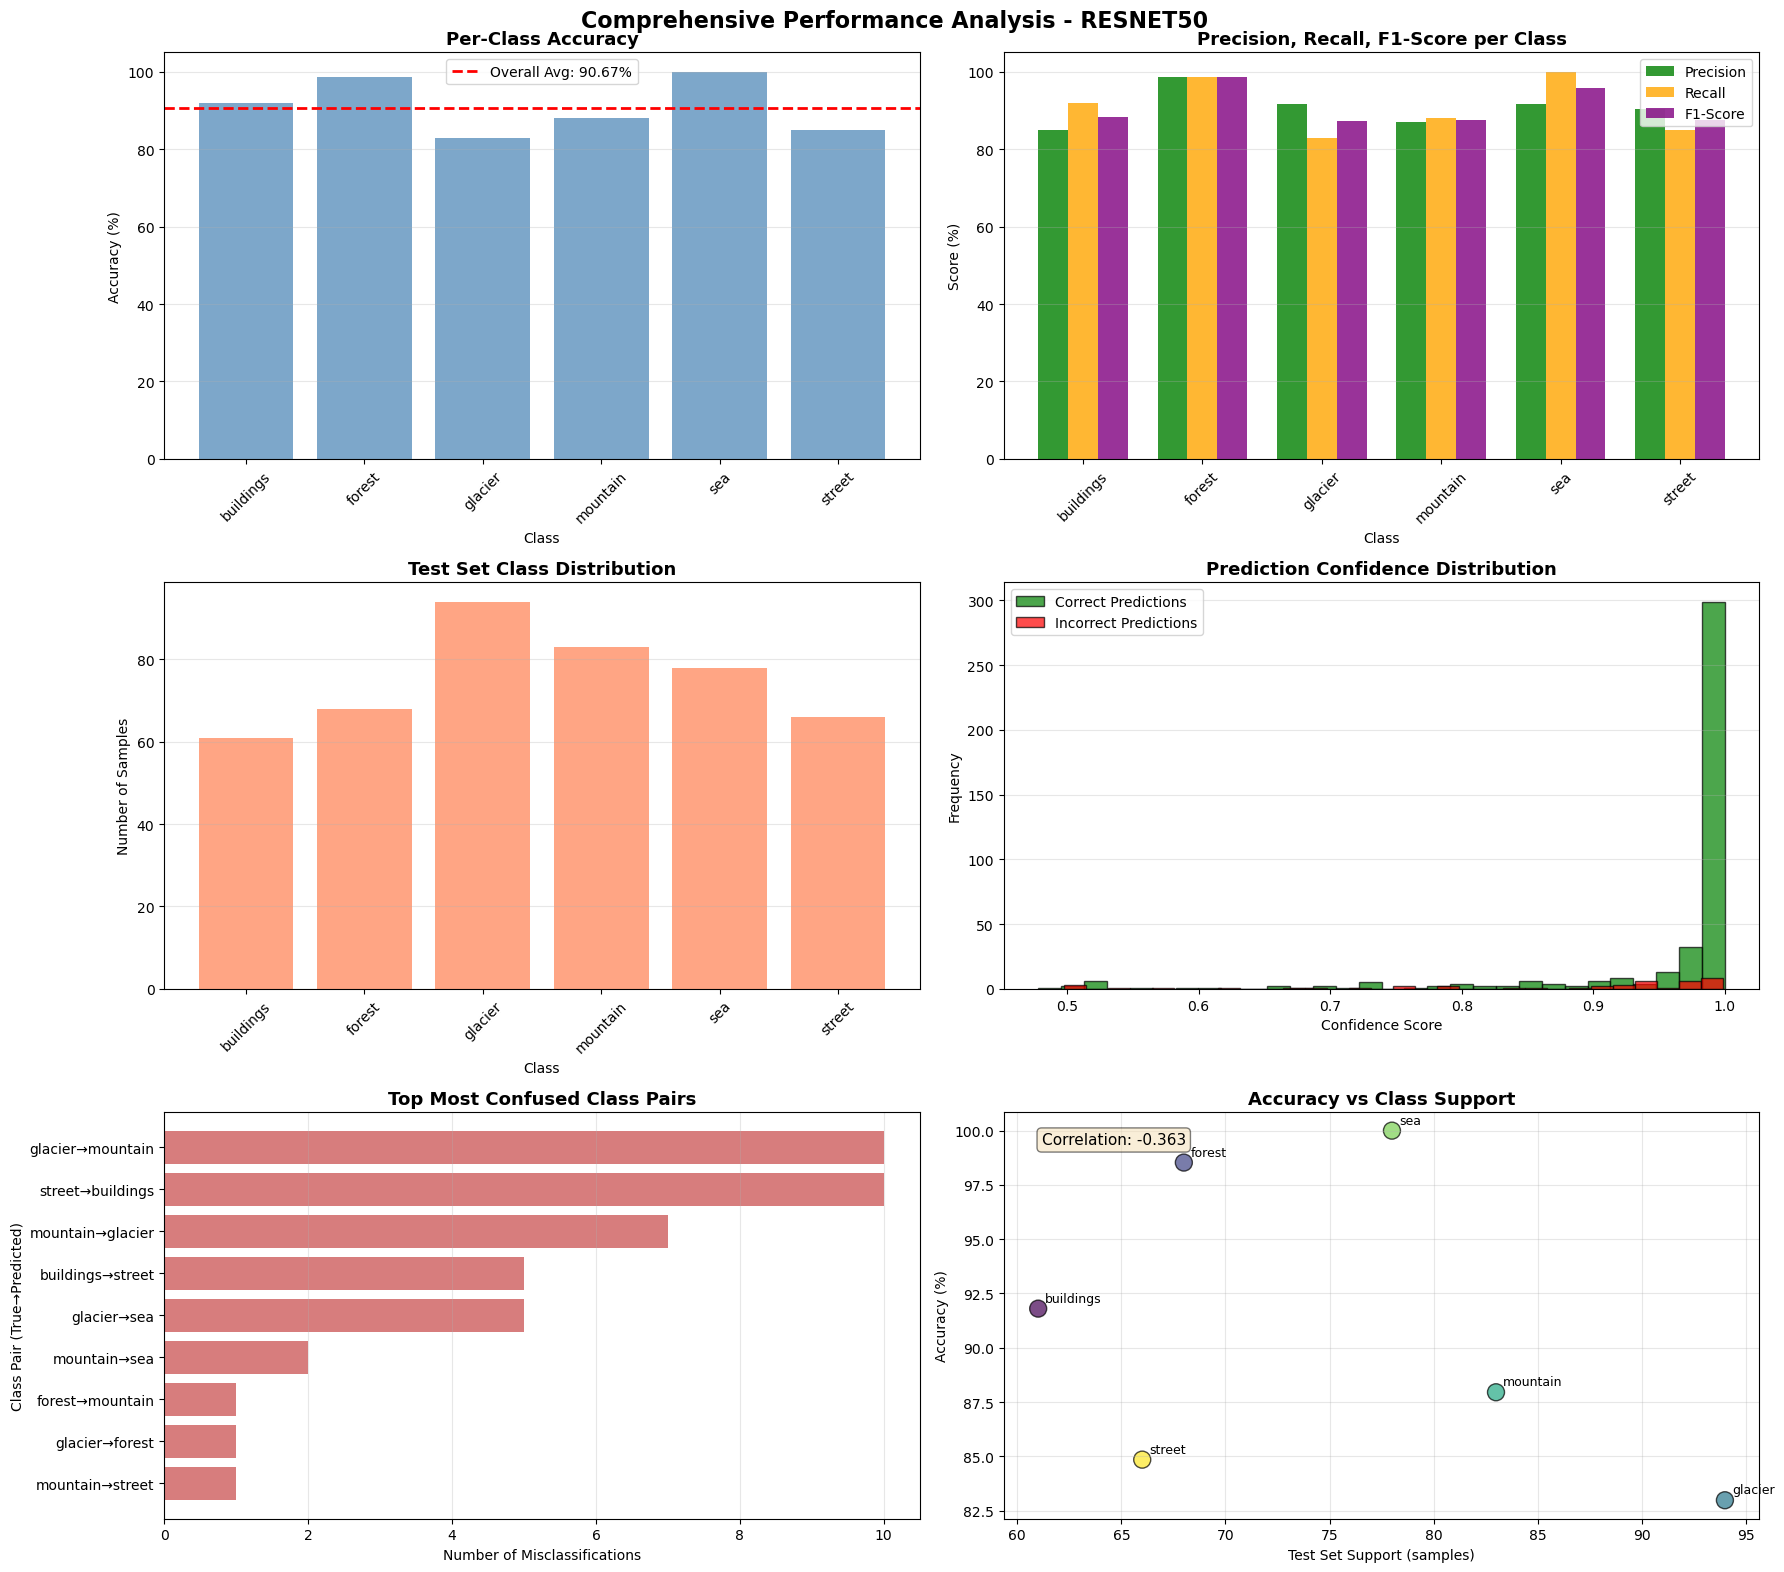

✅ Performance visualizations generated successfully!


In [20]:
# Performance Visualization - 6 Panel Analysis
fig, axes = plt.subplots(3, 2, figsize=(18, 16))

# 1. Per-Class Accuracy Bar Chart
axes[0, 0].bar(class_names, per_class_acc * 100, color='steelblue', alpha=0.7)
axes[0, 0].axhline(y=accuracy * 100, color='red', linestyle='--', linewidth=2, label=f'Overall Avg: {accuracy*100:.2f}%')
axes[0, 0].set_xlabel('Class')
axes[0, 0].set_ylabel('Accuracy (%)')
axes[0, 0].set_title('Per-Class Accuracy', fontsize=13, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3, axis='y')
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Precision, Recall, F1-Score Comparison
x_pos = np.arange(NUM_CLASSES)
width = 0.25
axes[0, 1].bar(x_pos - width, precision * 100, width, label='Precision', alpha=0.8, color='green')
axes[0, 1].bar(x_pos, recall * 100, width, label='Recall', alpha=0.8, color='orange')
axes[0, 1].bar(x_pos + width, f1 * 100, width, label='F1-Score', alpha=0.8, color='purple')
axes[0, 1].set_xlabel('Class')
axes[0, 1].set_ylabel('Score (%)')
axes[0, 1].set_title('Precision, Recall, F1-Score per Class', fontsize=13, fontweight='bold')
axes[0, 1].set_xticks(x_pos)
axes[0, 1].set_xticklabels(class_names, rotation=45)
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3, axis='y')

# 3. Class Support Distribution
axes[1, 0].bar(class_names, support, color='coral', alpha=0.7)
axes[1, 0].set_xlabel('Class')
axes[1, 0].set_ylabel('Number of Samples')
axes[1, 0].set_title('Test Set Class Distribution', fontsize=13, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='y')
axes[1, 0].tick_params(axis='x', rotation=45)

# 4. Confidence Distribution (Correct vs Incorrect)
axes[1, 1].hist(correct_confidences, bins=30, alpha=0.7, label='Correct Predictions', color='green', edgecolor='black')
axes[1, 1].hist(incorrect_confidences, bins=30, alpha=0.7, label='Incorrect Predictions', color='red', edgecolor='black')
axes[1, 1].set_xlabel('Confidence Score')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Prediction Confidence Distribution', fontsize=13, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3, axis='y')

# 5. Top Most Confused Class Pairs
cm_off_diagonal = cm.copy().astype(float)
np.fill_diagonal(cm_off_diagonal, 0)
confused_pairs = []
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        if i != j and cm_off_diagonal[i, j] > 0:
            confused_pairs.append((class_names[i], class_names[j], int(cm_off_diagonal[i, j])))

confused_pairs_sorted = sorted(confused_pairs, key=lambda x: x[2], reverse=True)[:10]
pair_labels = [f"{p[0]}\u2192{p[1]}" for p in confused_pairs_sorted]
pair_counts = [p[2] for p in confused_pairs_sorted]

axes[2, 0].barh(pair_labels, pair_counts, color='indianred', alpha=0.8)
axes[2, 0].set_xlabel('Number of Misclassifications')
axes[2, 0].set_ylabel('Class Pair (True\u2192Predicted)')
axes[2, 0].set_title('Top Most Confused Class Pairs', fontsize=13, fontweight='bold')
axes[2, 0].grid(True, alpha=0.3, axis='x')
axes[2, 0].invert_yaxis()

# 6. Accuracy vs Support Scatter Plot
axes[2, 1].scatter(support, per_class_acc * 100, s=150, alpha=0.7, c=range(NUM_CLASSES), cmap='viridis', edgecolors='black')
for i, cn in enumerate(class_names):
    axes[2, 1].annotate(cn, (support[i], per_class_acc[i] * 100), textcoords="offset points", xytext=(5, 5), fontsize=9)
axes[2, 1].set_xlabel('Test Set Support (samples)')
axes[2, 1].set_ylabel('Accuracy (%)')
axes[2, 1].set_title('Accuracy vs Class Support', fontsize=13, fontweight='bold')
axes[2, 1].grid(True, alpha=0.3)

# Add correlation coefficient
correlation = np.corrcoef(support, per_class_acc)[0, 1]
axes[2, 1].text(0.05, 0.95, f'Correlation: {correlation:.3f}', 
                transform=axes[2, 1].transAxes, fontsize=11, 
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle(f'Comprehensive Performance Analysis - {MODEL_ARCH.upper()}', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\u2705 Performance visualizations generated successfully!")

### Error Analysis

Analyzing misclassification patterns to understand model weaknesses.

In [21]:
# Error Analysis
print("\U0001f50d Analyzing misclassification patterns...\n")

# Find indices of misclassified samples
misclassified_indices = np.where(all_preds != all_labels)[0]
num_errors = len(misclassified_indices)

print(f"\u274c Total misclassifications: {num_errors} out of {len(all_labels)} ({num_errors/len(all_labels)*100:.2f}%)")

# Analyze error distribution by true class
error_by_class = {}
for idx in misclassified_indices:
    true_class = all_labels[idx]
    pred_class = all_preds[idx]
    
    if true_class not in error_by_class:
        error_by_class[true_class] = []
    error_by_class[true_class].append(pred_class)

# Classes with most errors
class_error_counts = {cls: len(errors) for cls, errors in error_by_class.items()}
sorted_error_classes = sorted(class_error_counts.items(), key=lambda x: x[1], reverse=True)

print(f"\n\U0001f534 Classes with Most Errors:")
print("="*60)
print(f"{'Class':<15} {'Errors':<12} {'Error Rate':<15}")
print("="*60)
for cls_idx, error_count in sorted_error_classes:
    total_samples = support[cls_idx]
    error_rate = (error_count / total_samples) * 100 if total_samples > 0 else 0
    print(f"{class_names[cls_idx]:<15} {error_count:<12} {error_rate:>6.2f}%")
print("="*60)

# Confidence analysis for errors
print(f"\n\U0001f4ca Confidence Analysis for Misclassifications:")
if len(incorrect_confidences) > 0:
    conf_quartiles = np.percentile(incorrect_confidences, [25, 50, 75])
    print(f"  25th percentile: {conf_quartiles[0]*100:.2f}%")
    print(f"  50th percentile (median): {conf_quartiles[1]*100:.2f}%")
    print(f"  75th percentile: {conf_quartiles[2]*100:.2f}%")
    
    high_confidence_errors = sum(1 for c in incorrect_confidences if c > 0.8)
    print(f"  High-confidence errors (>80%): {high_confidence_errors} ({high_confidence_errors/len(incorrect_confidences)*100:.1f}%)")

# Error patterns - which classes are commonly mistaken for each other
print(f"\n\U0001f504 Most Common Misclassification Patterns:")
print("="*70)
print(f"{'True Class':<15} {'Predicted As':<15} {'Count':<12} {'% of Class':<15}")
print("="*70)
for true_cls_idx, pred_list in sorted(error_by_class.items(), key=lambda x: len(x[1]), reverse=True)[:5]:
    pred_counts = {}
    for pred in pred_list:
        pred_counts[pred] = pred_counts.get(pred, 0) + 1
    
    most_common_pred = max(pred_counts.items(), key=lambda x: x[1])
    pct_of_class = (most_common_pred[1] / support[true_cls_idx]) * 100
    print(f"{class_names[true_cls_idx]:<15} {class_names[most_common_pred[0]]:<15} {most_common_pred[1]:<12} {pct_of_class:>6.2f}%")
print("="*70)

print("\n\u2705 Error analysis complete!")

🔍 Analyzing misclassification patterns...

❌ Total misclassifications: 42 out of 450 (9.33%)

🔴 Classes with Most Errors:
Class           Errors       Error Rate     
glacier         16            17.02%
street          10            15.15%
mountain        10            12.05%
buildings       5              8.20%
forest          1              1.47%

📊 Confidence Analysis for Misclassifications:
  25th percentile: 76.94%
  50th percentile (median): 93.08%
  75th percentile: 97.26%
  High-confidence errors (>80%): 29 (69.0%)

🔄 Most Common Misclassification Patterns:
True Class      Predicted As    Count        % of Class     
glacier         mountain        10            10.64%
street          buildings       10            15.15%
mountain        glacier         7              8.43%
buildings       street          5              8.20%
forest          mountain        1              1.47%

✅ Error analysis complete!


### Final Summary Report

Comprehensive summary of model performance and key findings.

In [22]:
# Final Summary Report
print("\n" + "="*80)
print(" "*25 + "\U0001f3af MODEL EVALUATION SUMMARY")
print("="*80)

print(f"\n\U0001f4e6 Model Architecture: {MODEL_ARCH.upper()}")
print(f"\U0001f4ca Dataset: Landscape (Intel Image Classification)")
print(f"\U0001f522 Number of Classes: {NUM_CLASSES} ({', '.join(class_names)})")
print(f"\U0001f9ea Test Set Size: {len(all_labels)} images")

print(f"\n{'\u2500'*80}")
print("\U0001f4c8 OVERALL PERFORMANCE METRICS:")
print(f"{'\u2500'*80}")
print(f"  Overall Accuracy:        {accuracy * 100:>6.2f}%")
print(f"  Balanced Accuracy:       {balanced_acc * 100:>6.2f}%")
print(f"  Macro Precision:         {macro_precision:>6.2f}%")
print(f"  Macro Recall:            {macro_recall:>6.2f}%")
print(f"  Macro F1-Score:          {macro_f1:>6.2f}%")
print(f"  Weighted Precision:      {weighted_precision:>6.2f}%")
print(f"  Weighted Recall:         {weighted_recall:>6.2f}%")
print(f"  Weighted F1-Score:       {weighted_f1:>6.2f}%")

print(f"\n{'\u2500'*80}")
print("\u2705 BEST PERFORMING CLASSES (Top-3):")
print(f"{'\u2500'*80}")
for i, metric in enumerate(sorted_by_f1[:3], 1):
    print(f"  {i}. {metric['class']}: F1={metric['f1']:6.2f}%, "
          f"Accuracy={metric['accuracy']:6.2f}%, Support={metric['support']}")

print(f"\n{'\u2500'*80}")
print("\u26a0\ufe0f  WORST PERFORMING CLASSES (Bottom-3):")
print(f"{'\u2500'*80}")
for i, metric in enumerate(sorted_by_f1[-3:], 1):
    print(f"  {i}. {metric['class']}: F1={metric['f1']:6.2f}%, "
          f"Accuracy={metric['accuracy']:6.2f}%, Support={metric['support']}")

print(f"\n{'\u2500'*80}")
print("\U0001f504 CONFUSION INSIGHTS:")
print(f"{'\u2500'*80}")
print(f"  Most confused pair: {class_names[most_confused_idx[0]]} \u2192 {class_names[most_confused_idx[1]]} "
      f"({most_confused_value} misclassifications)")
print(f"  Total misclassifications: {num_errors}")
print(f"  Error rate: {num_errors/len(all_labels)*100:.2f}%")

print(f"\n{'\u2500'*80}")
print("\U0001f3b2 CONFIDENCE STATISTICS:")
print(f"{'\u2500'*80}")
print(f"  Avg confidence (correct):   {avg_correct_conf * 100:>6.2f}%")
print(f"  Avg confidence (incorrect): {avg_incorrect_conf * 100:>6.2f}%")
print(f"  Confidence gap:             {(avg_correct_conf - avg_incorrect_conf) * 100:>6.2f}%")

print(f"\n{'\u2500'*80}")
print("\U0001f4be MODEL ARTIFACTS:")
print(f"{'\u2500'*80}")
print(f"  Saved model: {model_name}")
print(f"  Training history: Stored in 'history' dictionary")
print(f"  Metrics tracked: Top-1 Acc, Top-5 Acc, Loss, Learning Rate")

print(f"\n{'\u2500'*80}")
print("\U0001f680 TRAINING CONFIGURATION:")
print(f"{'\u2500'*80}")
print(f"  Optimizer: AdamW (lr={LEARNING_RATE}, weight_decay={WEIGHT_DECAY})")
print(f"  Scheduler: CosineAnnealingWarmRestarts (T_0={COSINE_T_0}, T_mult={COSINE_T_MULT})")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Max epochs: {MAX_EPOCHS}")
print(f"  Early stopping patience: {EARLY_STOPPING_PATIENCE}")
print(f"  Dropout rate: {DROPOUT_RATE}")
print(f"  Gradient clipping: max_norm={MAX_GRAD_NORM}")
print(f"  Train/Val/Test split: {TRAIN_SPLIT*100:.0f}%/{VAL_SPLIT*100:.0f}%/{TEST_SPLIT*100:.0f}%")
print(f"  Augmentation: {'ENABLED' if USE_AUGMENTATION else 'DISABLED'}")
print(f"  Weighted Sampler: {'ENABLED' if USE_WEIGHTED_SAMPLER else 'DISABLED'}")

print(f"\n{'='*80}")
print(" "*20 + "\u2705 EVALUATION COMPLETE!")
print("="*80 + "\n")


                         🎯 MODEL EVALUATION SUMMARY

📦 Model Architecture: RESNET50
📊 Dataset: Landscape (Intel Image Classification)
🔢 Number of Classes: 6 (buildings, forest, glacier, mountain, sea, street)
🧪 Test Set Size: 450 images

────────────────────────────────────────────────────────────────────────────────
📈 OVERALL PERFORMANCE METRICS:
────────────────────────────────────────────────────────────────────────────────
  Overall Accuracy:         90.67%
  Balanced Accuracy:        91.02%
  Macro Precision:          90.69%
  Macro Recall:             91.02%
  Macro F1-Score:           90.75%
  Weighted Precision:       90.74%
  Weighted Recall:          90.67%
  Weighted F1-Score:        90.60%

────────────────────────────────────────────────────────────────────────────────
✅ BEST PERFORMING CLASSES (Top-3):
────────────────────────────────────────────────────────────────────────────────
  1. forest: F1= 98.53%, Accuracy= 98.53%, Support=68
  2. sea: F1= 95.71%, Accuracy=100.0